1. Importar librerias

In [56]:
from openseespy.opensees import *
import matplotlib.pyplot as plt
import opseestools.analisis as an
import opseestools.utilidades as ut
import opsvis as opsv
import numpy as np

2. Creación del modelo 2D

In [57]:
wipe()
model('basic','-ndm',2,'-ndf',3)

3. Creación de nodos y apoyos

In [58]:
x1=6.0 #en metros
y1=4.0
y2=8.0

node(1,0.0,0.0)
node(2,x1,0.0)
node(3,0.0,y1)
node(4,x1,y1)
node(5,0.0,y2)
node(6,x1,y2)

#Apoyos
empotrado=[1,1,1]
pineado=[1,1,0]
fix(1,*empotrado)
fix(2,*empotrado)

#Diafragmas
equalDOF(3,4,1)
equalDOF(5,6,1)

4. Creación de Materiales

In [59]:
matTag=1
Es=200e6 # en kN/m2
uniaxialMaterial('Elastic',matTag,Es)

5. Creación de las secciones trasnversales

In [60]:
A_col = 0.00419   # Área perfil W10x22 en m4
I_col = 0.0000491  # Inercia W10x22 en m4
A_viga = 0.00419 
I_viga = 0.0000491

6. Creación de elementos

<Axes: >

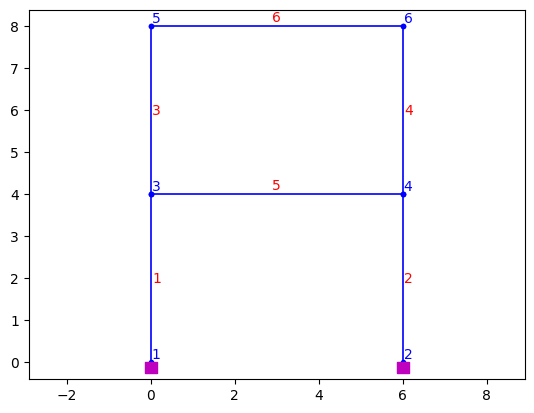

In [61]:
trans_Col_Tag=1
trans_Viga_Tag=2
geomTransf('Linear',trans_Col_Tag)
geomTransf('Linear',trans_Viga_Tag)

#Columnas
element('elasticBeamColumn', 1, 1, 3, A_col*1e6,Es, I_col, trans_Col_Tag) # Col 1P Izq
element('elasticBeamColumn', 2, 2, 4, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 1P Der
element('elasticBeamColumn', 3, 3, 5, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 2P Izq
element('elasticBeamColumn', 4, 4, 6, A_col*1e6, Es, I_col, trans_Col_Tag) # Col 2P Der

#Vigas
element('elasticBeamColumn', 5, 3, 4, A_viga, Es, I_viga*1e6, trans_Viga_Tag) # Viga 1P
element('elasticBeamColumn', 6, 5, 6, A_viga, Es, I_viga*1e6, trans_Viga_Tag) # Viga Techo

opsv.plot_model()

Aplicación de cargas

<Axes: >

<Figure size 640x480 with 0 Axes>

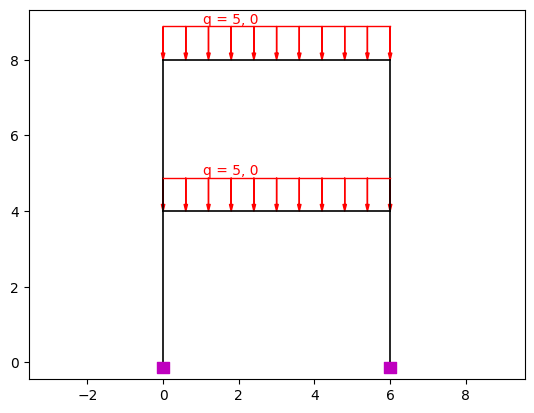

In [62]:
#ASIGNACIÓN DE CARGAS SOBREIMPUESTAS
timeSeries('Linear',1)
pattern('Plain',1,1)

vigas=[5,6] #Tags de los elementos viga
wviga=5 #kN valor de carga distribuida sobre la viga
eleLoad('-ele',*vigas,'-type','beamUniform',-wviga)

#ASIGACION DE MASA EN LOS NODOS

mass(3,1,1,0)
mass(4,1,1,0)
mass(5,1,1,0)
mass(6,1,1,0)

plt.figure() #figura del modelo con cargas
opsv.plot_load()

Análisis estático

In [63]:
an.gravedad()
loadConst('-time',0.0) #aplicar las cargas de gravedad en el paso inicial, o sea fijar las cargas de gravedad

Cálculo del periodo fundamental

Periodos: T1=0.24s, T2=0.09s


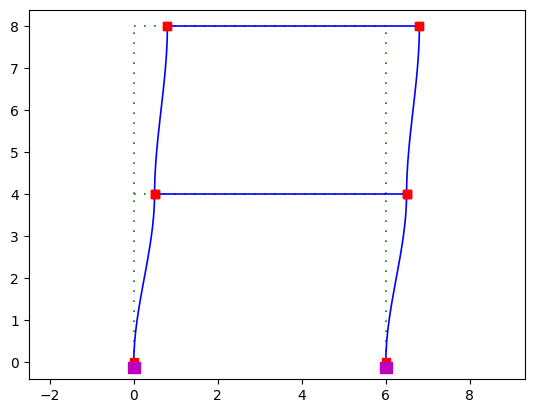

In [64]:
eig=eigen(2) #calcula las frecuencias de la canitdad de modos indicada, en este caos 1. esto es w^2
T1=2*3.1416/np.sqrt(eig[0])
T2=2*3.1416/np.sqrt(eig[1])
print(f"Periodos: T1={T1:.2f}s, T2={T2:.2f}s")

opsv.plot_mode_shape(1) #para graficar el modo 1

Registro sismico

In [65]:
xi = 0.05  # 5% de amortiguamiento

# Se extraen las frecuencias angulares de los dos únicos modos del sistema
wn1 = np.sqrt(eig[0])
wn2 = np.sqrt(eig[1])

# Cálculo de coeficientes de Rayleigh (Masa y Rigidez Inicial)
a0 = xi * (2.0 * wn1 * wn2) / (wn1 + wn2)
a1 = xi * 2.0 / (wn1 + wn2)

# Asignación en OpenSees: rayleigh(alphaM, betaKcurr, betaKinit, betaKcomm)
# Usaremos la rigidez inicial (betaKinit = a1)
rayleigh(a0, 0.0, a1, 0.0)

# Es fundamental reiniciar el tiempo a 0 luego del análisis de gravedad
loadConst('-time', 0.0) 
wipeAnalysis()

dt = 0.01
npts = 3000
g = 9.81 # m/s2 (Factor de escala para pasar de fracciones de g a aceleración)

# Serie de tiempo leyendo el archivo txt
timeSeries('Path', 2, '-filePath', 'Sismo1.txt', '-dt', dt, '-factor', g)

# Patrón de carga de excitación en la base (Dirección 1 = X)
pattern('UniformExcitation', 2, 1, '-accel', 2)


Análisis dinámico

Análisis dinámico completado con éxito.
Desplazamiento Máximo Nudo 4 (Piso 1): 0.00813 m
Desplazamiento Máximo Nudo 6 (Piso 2): 0.01301 m
Fuerza Axial Máxima en la base (Columna 1): 14.98 kN


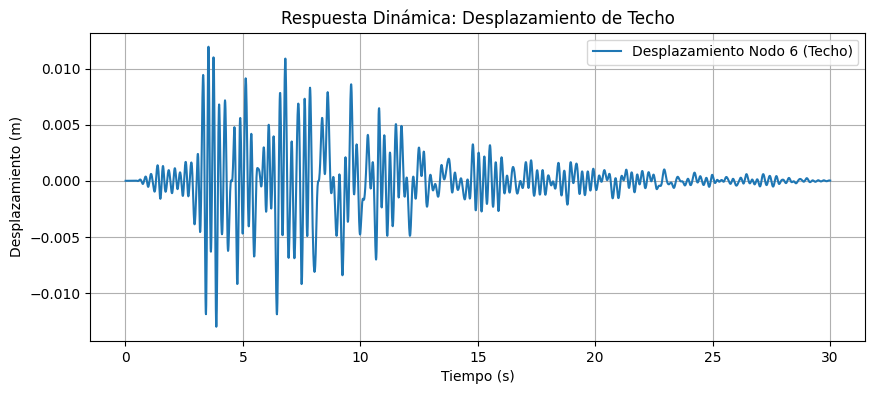

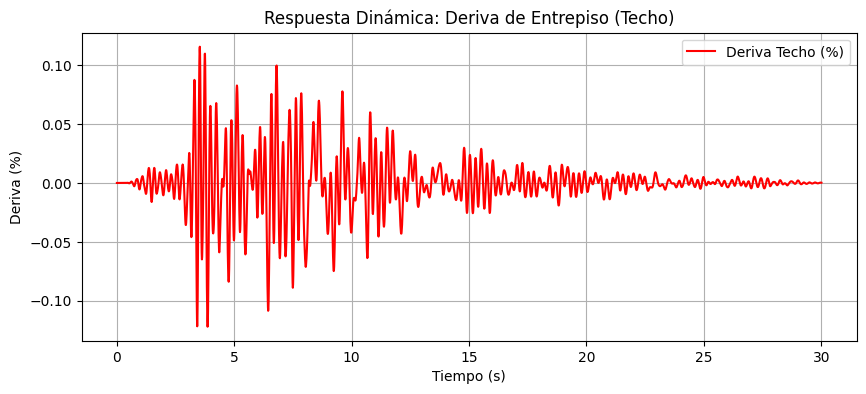

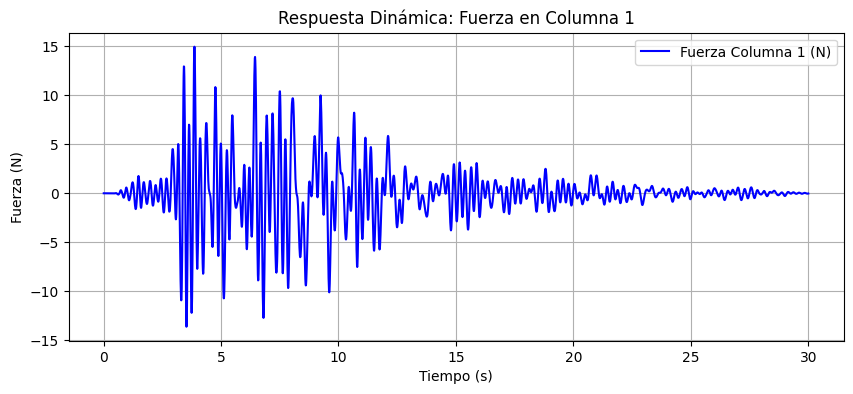

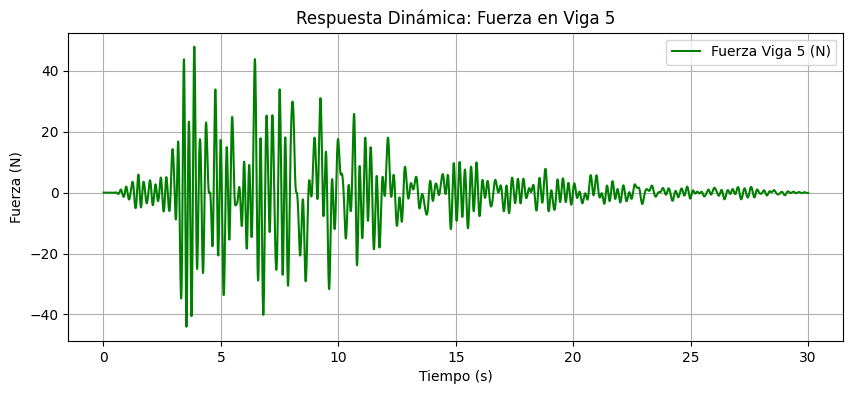

5

In [66]:
constraints('Transformation') # Necesario por el uso de equalDOF
numberer('RCM')
system('BandGeneral')
test('NormDispIncr', 1.0e-8, 10, 0) # Tolerancia estricta
algorithm('Newton')
integrator('Newmark', 0.5, 0.25)    # Aceleración promedio (Incondicionalmente estable)
analysis('Transient')


#iniciar variables de salida

time_out = np.zeros(npts)
disp_techo = np.zeros(npts)
disp_entrepiso = np.zeros(npts)
deriva_techo = np.zeros(npts)
fuerzas_col1=np.zeros(npts)
fuerzas_viga5=np.zeros(npts)
max_disp_4 = 0.0
max_disp_6 = 0.0
max_f_axial_col1=0.0

#CALCULO DE LOS DESPLAZAMIENTOS, DERIVAS Y FUERZAS
h_piso2 = y2 - y1 # Altura del segundo piso (4.0 m)

for i in range(npts):
    ok = analyze(1, dt)
    if ok != 0:
        print(f"El análisis falló en el paso {i}, t = {getTime():.2f} s")
        break
    
    time_out[i] = getTime() #tiempo actual
    
    # Extraer desplazamientos en X (GDL 1) de los nodos 6 (Techo) y 4 (Piso 1)
    u_techo = nodeDisp(6, 1)
    u_piso1 = nodeDisp(4, 1)

    #Extraer fuerzas
    f_col1 = eleForce(1)
    f_viga5 = eleForce(5)
    
    # Almacenar desplazamiento total del techo
    disp_techo[i] = u_techo
    disp_entrepiso[i] = u_piso1
    fuerzas_col1[i]= f_col1[0] #fuerza axial
    fuerzas_viga5[i] = f_viga5[2] #momento flector


    # Calcular y almacenar la deriva del techo (Drift del piso 2)
    deriva_techo[i] = (u_techo - u_piso1) / h_piso2
    
    # Actualizar máximos absolutos
    if abs(u_piso1) > max_disp_4:
        max_disp_4 = abs(u_piso1)
    if abs(u_techo) > max_disp_6:
        max_disp_6 = abs(u_techo)
    if abs(f_col1[0]) > max_f_axial_col1:
        max_f_axial_col1 = abs(f_col1[0])

print("Análisis dinámico completado con éxito.")

#DESPLAZAMIENTO MÁXIMO DE LOS NODOS 4 Y 6
print(f"Desplazamiento Máximo Nudo 4 (Piso 1): {max_disp_4:.5f} m")
print(f"Desplazamiento Máximo Nudo 6 (Piso 2): {max_disp_6:.5f} m")
print(f"Fuerza Axial Máxima en la base (Columna 1): {max_f_axial_col1:.2f} kN")


#DESPLAZAMIENTOS DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, disp_techo, label='Desplazamiento Nodo 6 (Techo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento (m)')
plt.title('Respuesta Dinámica: Desplazamiento de Techo')
plt.grid(True)
plt.legend()
plt.show()

#DERIVA DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, deriva_techo * 100, color='red', label='Deriva Techo (%)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Deriva (%)')
plt.title('Respuesta Dinámica: Deriva de Entrepiso (Techo)')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA AXIAL COLUMNA 1 EN EL TIEMPO

plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_col1, color='blue', label='Fuerza Columna 1 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Columna 1')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA VIGA 5 EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_viga5, color='green', label='Fuerza Viga 5 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Viga 5')
plt.grid(True)
plt.legend()
plt.show()

#EXTRACCIÓN DE FUERZAS EN ELEMENTOS
recorder('Element', '-file', 'Fuerzas_Columnas_Piso1.txt', '-time', '-ele', 1, 2, 'localForce')
recorder('Element', '-file', 'Fuerzas_Vigas.txt', '-time', '-ele', 5, 6, 'localForce')